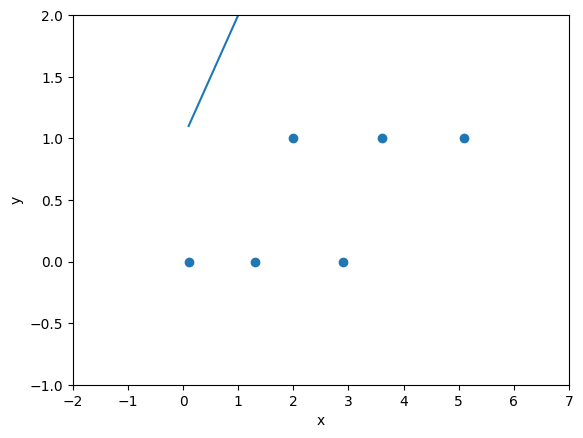

In [476]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
df = pd.DataFrame({'x': [0.1, 1.3, 2, 2.9, 3.6, 5.1], 'y': [0, 0, 1, 0, 1, 1]})
df.plot.scatter(x='x', y='y');

df = df[['x', 'y']].copy()
m, b = 1, 1
df['y_pred'] = df['x'] * m + b
def chart():
  plt.xlim(-2, 7)
  plt.ylim(-1, 2)
  plt.scatter(df['x'], df['y'])
  plt.plot(df['x'], df['y_pred']);
chart()

/home/tim/myenv/lib64/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but SGDRegressor was fitted with feature names
  warnings.warn(


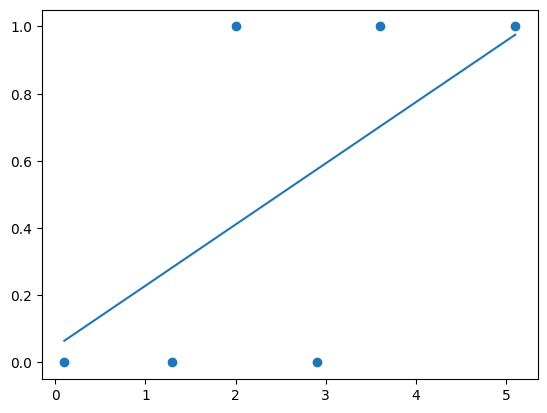

In [477]:
from sklearn.linear_model import SGDRegressor
regressor = SGDRegressor()
regressor.fit(df[['x']], df['y'])
plt.scatter(df['x'], df['y'])
plt.plot(df['x'], regressor.predict(df[['x']].to_numpy()))

In [478]:
df['y'].to_numpy(), regressor.predict(df[['x']].to_numpy())

/home/tim/myenv/lib64/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but SGDRegressor was fitted with feature names
  warnings.warn(


(array([0, 0, 1, 0, 1, 1]),
 array([0.06454013, 0.28314268, 0.41066082, 0.57461273, 0.70213088,
        0.97538405]))

/home/tim/myenv/lib64/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but SGDRegressor was fitted with feature names
  warnings.warn(


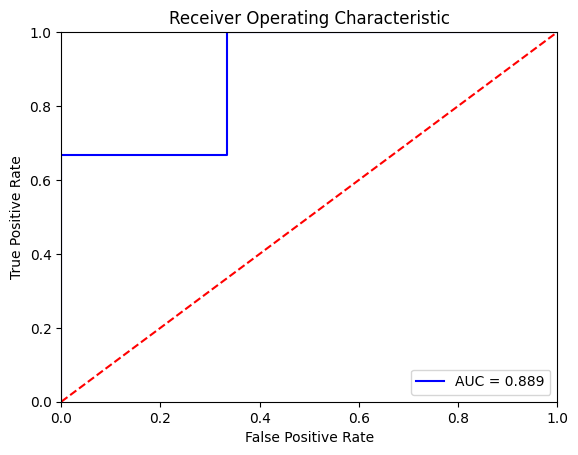

In [479]:
import sklearn.metrics as metrics

fpr, tpr, threshhold = metrics.roc_curve(df['y'].to_numpy(), regressor.predict(df[['x']].to_numpy()))
roc_auc = metrics.auc(fpr, tpr)
import matplotlib.pyplot as plt
plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr, 'b', label = 'AUC = %0.3f' % roc_auc)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

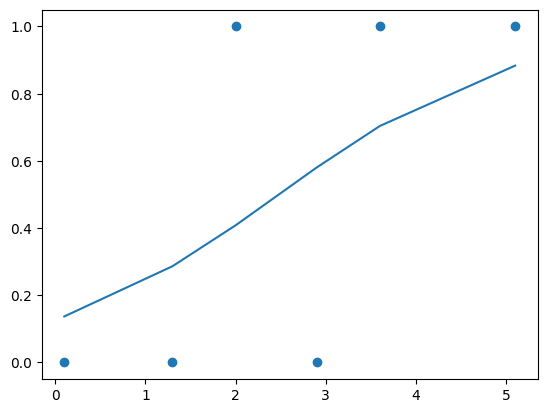

In [480]:
from sklearn.linear_model import LogisticRegression
logressor = LogisticRegression()
logressor.fit(df[['x']], df['y'])
logressor.predict_proba(df[['x']])[:, 0]

plt.scatter(df['x'], df['y'])
plt.plot(df['x'], logressor.predict_proba(df[['x']])[:, 1])

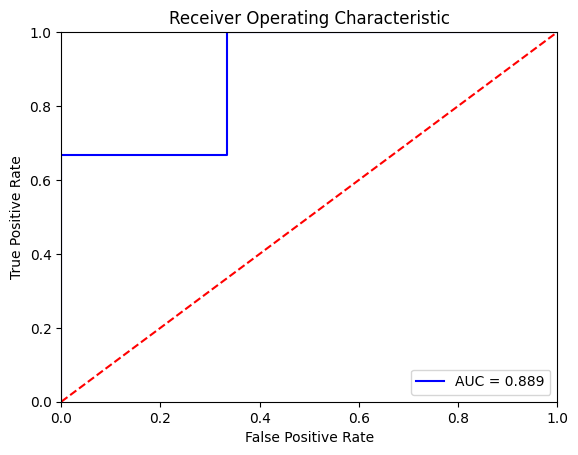

In [481]:
fpr, tpr, threshhold = metrics.roc_curve(df['y'].to_numpy(), logressor.predict_proba(df[['x']])[:, 1])
roc_auc = metrics.auc(fpr, tpr)
import matplotlib.pyplot as plt
plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr, 'b', label = 'AUC = %0.3f' % roc_auc)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

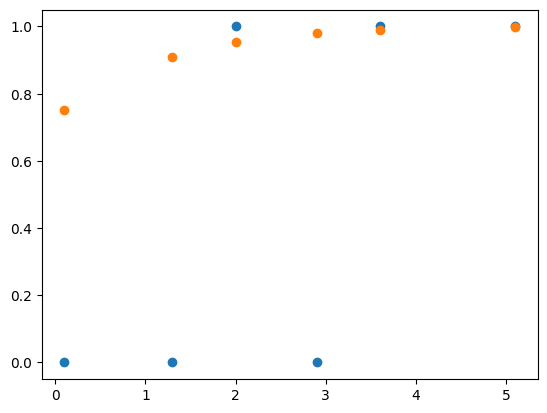

In [482]:
def sigmoid(x, m, c):
    return 1/(1 + np.exp(-(m*x + c)))

df = df[['x', 'y']].copy()
m, b = 1, 1
df['y_pred'] = sigmoid(df['x'].to_numpy(), m, b)

plt.scatter(df['x'], df['y'])
plt.scatter(df['x'].to_numpy(), df['y_pred'].to_numpy())

In [483]:
from sympy import *
from sympy.abc import x, y, m, b
x, y, m, b = symbols('x y m b', real=True)
e = Abs(y - 1/(1+exp(-(m*x+b))))
e

Abs(y - 1/(exp(-b - m*x) + 1))

In [484]:
init_printing(use_latex='matplotlib')
init_printing(pretty_print=False)

In [485]:
e

Abs(y - 1/(exp(-b - m*x) + 1))

In [486]:
diff(e, m)

-x*exp(-b - m*x)*sign(y - 1/(exp(-b - m*x) + 1))/(exp(-b - m*x) + 1)**2

In [487]:
diff(e, b)

-exp(-b - m*x)*sign(y - 1/(exp(-b - m*x) + 1))/(exp(-b - m*x) + 1)**2

In [488]:
diff(e, b).evalf(subs={
    y: 1,
    x: 1,
    m: 1,
    b: 1
})

-0.104993585403507

In [489]:
df = df[['x', 'y']].copy()
m, b = 1, 1
nu = 0.1
n = 1000
df['y_pred'] = sigmoid(df['x'], m, b)
for i in range(n):
  df['m_change'] = df['x']*np.exp(-b - m*df['x'])*np.sign(df['y'] - 1/(np.exp(-b - m*df['x']) + 1))/(np.exp(-b - m*df['x']) + 1)**2
  df['b_change'] = np.exp(-b - m*df['x'])*np.sign(df['y'] - 1/(np.exp(-b - m*df['x']) + 1))/(np.exp(-b - m*df['x']) + 1)**2
  m = m + nu * df['m_change'].mean()
  b = b + nu * df['b_change'].mean()
  df['y_pred'] = sigmoid(df['x'], m, b)
  df['err_sq'] = (df['y']-df['y_pred'])**2
  print(df['err_sq'].mean())

0.39166041132020374
0.391317003240471
0.3909721014116863
0.3906257008390266
0.3902777965629731
0.3899283836605915
0.38957745724683046
0.38922501247584257
0.38887104454232474
0.38851554868287885
0.38815852017739466
0.38779995435045195
0.387439846572746
0.38707819226253043
0.38671498688708555
0.38635022596420393
0.3859839050637001
0.3856160198089404
0.3852465658783934
0.3848755390072039
0.38450293498878546
0.38412874967643756
0.38375297898498073
0.3833756188924162
0.3829966654416048
0.38261611474196844
0.3822339629712126
0.3818502063770692
0.3814648412790622
0.38107786407029337
0.38068927121924917
0.3802990592716289
0.3799072248521927
0.3795137646666324
0.37911867550345985
0.3787219542359181
0.3783235978239121
0.37792360331595876
0.3775219678511566
0.3771186886611771
0.37671376307227233
0.3763071885073037
0.3758989624877893
0.3754890826359683
0.37507754667688564
0.37466435244049173
0.3742494978637627
0.3738329809928358
0.3734147999851616
0.37299495311167236
0.3725734387589677
0.372150255

In [490]:
m, b

(1.54554139350547, -2.762155983990797)

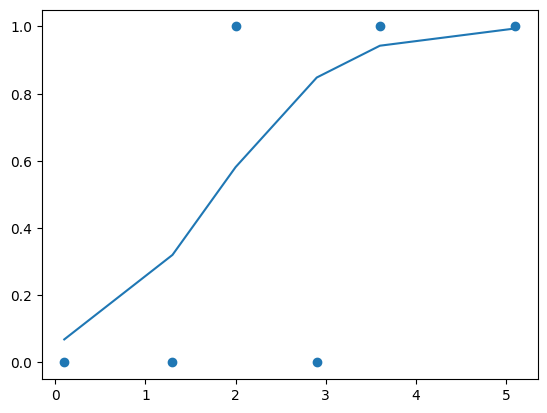

In [491]:
plt.scatter(df['x'], df['y'])
plt.plot(df['x'], df['y_pred'])

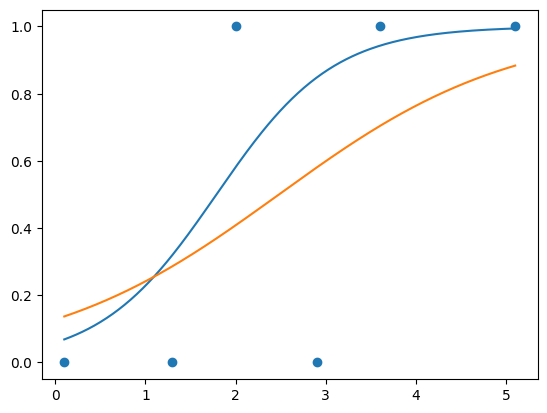

In [492]:
plt.scatter(df['x'], df['y'])
xnew = np.linspace(df['x'].min(), df['x'].max(), 300)
ynew = 1 / (1 + np.exp(-(xnew * m + b)))
ynew1 = 1 / (1 + np.exp(-(xnew * logressor.coef_[0, 0] + logressor.intercept_[0])))
plt.plot(xnew, ynew)
plt.plot(xnew, ynew1)

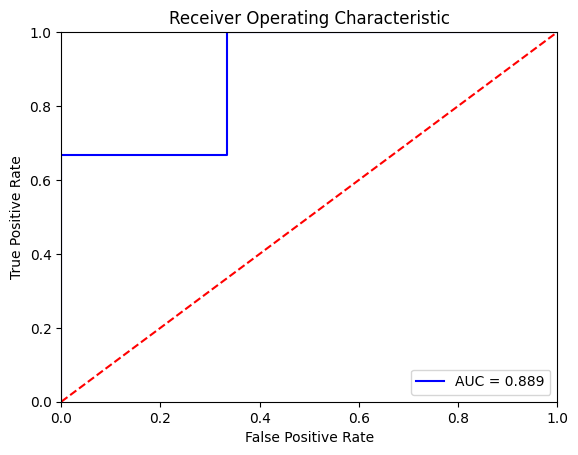

In [493]:
fpr, tpr, threshhold = metrics.roc_curve(df['y'].to_numpy(), df['y_pred'].to_numpy())
roc_auc = metrics.auc(fpr, tpr)
import matplotlib.pyplot as plt
plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr, 'b', label = 'AUC = %0.3f' % roc_auc)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

In [494]:
logressor.coef_, logressor.intercept_

(array([[0.77335654]]), array([-1.91795431]))

In [495]:
L_plus = df.loc[df['y'] == 1]['y_pred'].to_numpy().prod()
L_minus = (1 - df.loc[df['y'] == 0]['y_pred'].to_numpy()).prod()
likelihood = L_plus * L_minus
-np.log(likelihood)/df['y'].size

0.49145512225632704

In [496]:
plus_sum = np.log(df.loc[df['y'] == 1]['y_pred'].to_numpy()).sum()
minus_sum = np.log(1 - df.loc[df['y'] == 0]['y_pred'].to_numpy()).sum()
-(plus_sum + minus_sum)/df['y'].size

0.4914551222563271

In [497]:
y_true, y_pred = df['y'], df['y_pred']
log_likelihood_elements = y_true*np.log(y_pred) + (1-y_true)*np.log(1-y_pred)
-np.sum(log_likelihood_elements)/len(y_true)

# use log_loss function
df['y_pred_reverse'] = 1 - df['y_pred']
y_pred_proba = df[['y_pred_reverse', 'y_pred']].values.tolist()
print(y_pred_proba)
from sklearn.metrics import log_loss
log_loss(df['y'], y_pred_proba)

[[0.9313492219044557, 0.06865077809554426], [0.679821622217777, 0.320178377782223], [0.41850177140431455, 0.5814982285956855], [0.15188223396630196, 0.848117766033698], [0.057227360667211236, 0.9427726393327888], [0.005939901455502161, 0.9940600985444978]]


0.49145512225632704

In [498]:
df = df[['x', 'y']].copy()
m, b = 1, 1
nu = 0.1
n = 1000
df['y_pred'] = sigmoid(df['x'], m, b)
for i in range(n):
  df['err'] = df['y'] - df['y_pred']
  df['m_change'] = df['x'] * df['err']
  df['b_change'] = df['err']
  df['l'] = df['y']*(np.log( df['y_pred'])) + (1-df['y'])*(np.log(1-df['y_pred']))
  m = m + nu * df['m_change'].mean()
  b = b + nu * df['b_change'].mean()
  df['y_pred'] = sigmoid(df['x'], m, b)

  if not i%100: print( df['l'].sum())

-7.763749916849438
-3.2251460543612582
-2.8405348419079197
-2.692334442227154
-2.6237790238172876
-2.5882366830298125
-2.5684035814165025
-2.5567696254753502
-2.549699312918941
-2.5452895909554702


In [499]:
# use log_loss function
df['y_pred_reverse'] = 1 - df['y_pred']
y_pred_proba = df[['y_pred_reverse', 'y_pred']].values.tolist()
print(y_pred_proba)
from sklearn.metrics import log_loss
log_loss(df['y'], y_pred_proba)

[[0.9467199298299404, 0.05328007017005963], [0.8016897447789815, 0.1983102552210185], [0.6302369769215617, 0.3697630230784384], [0.35958163152731526, 0.6404183684726847], [0.19141595450952298, 0.808584045490477], [0.03586304999445522, 0.9641369500055448]]


0.423747528309186

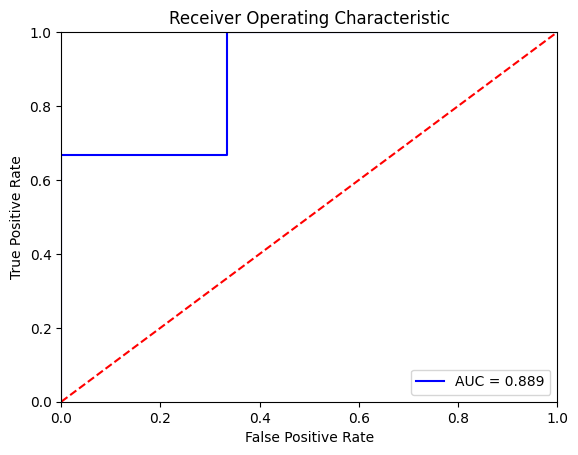

In [500]:
fpr, tpr, threshhold = metrics.roc_curve(df['y'].to_numpy(), df['y_pred'].to_numpy())
roc_auc = metrics.auc(fpr, tpr)
import matplotlib.pyplot as plt
plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr, 'b', label = 'AUC = %0.3f' % roc_auc)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()